In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\User\Downloads\archive (41)\churn_analysis_mysql.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,15810218,Sun,610,Spain,Male,29,9,0.00,3,0,1,83912.24,0,0,5,SILVER,691
996,997,15645621,Hunter,811,Spain,Male,44,3,0.00,2,0,1,78439.73,0,0,5,PLATINUM,859
997,998,15608114,Manfrin,587,Spain,Male,62,7,121286.27,1,0,1,6776.92,0,0,5,DIAMOND,500
998,999,15659557,Artamonova,811,Germany,Female,28,4,167738.82,2,1,1,9903.42,0,0,4,GOLD,513


In [3]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           1000 non-null   int64  
 1   CustomerId          1000 non-null   int64  
 2   Surname             1000 non-null   object 
 3   CreditScore         1000 non-null   int64  
 4   Geography           1000 non-null   object 
 5   Gender              1000 non-null   object 
 6   Age                 1000 non-null   int64  
 7   Tenure              1000 non-null   int64  
 8   Balance             1000 non-null   float64
 9   NumOfProducts       1000 non-null   int64  
 10  HasCrCard           1000 non-null   int64  
 11  IsActiveMember      1000 non-null   int64  
 12  EstimatedSalary     1000 non-null   float64
 13  Exited              1000 non-null   int64  
 14  Complain            1000 non-null   int64  
 15  Satisfaction Score  1000 non-null   int64  
 16  Card Ty

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [7]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Complain', 'Satisfaction Score', 'Card Type',
       'Point Earned'],
      dtype='object')

In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_cols = ['Geography', 'Gender', 'Card Type']

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [9]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377
3,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425


In [10]:
X= df.drop('Exited',axis=1)
y=df['Exited']

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [12]:
rf_model= RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [13]:
y_pred=rf_model.predict(X_test)

In [14]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0])

In [15]:
print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))
print("\nClassification Report:")
print(classification_report(y_test,y_pred))
      

Confusion Matrix
[[154   2]
 [  0  44]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       156
           1       0.96      1.00      0.98        44

    accuracy                           0.99       200
   macro avg       0.98      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



In [16]:
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

               Feature  Importance
10            Complain    0.692223
3                  Age    0.067471
6        NumOfProducts    0.055112
5              Balance    0.033274
9      EstimatedSalary    0.032018
0          CreditScore    0.027935
13        Point Earned    0.022989
8       IsActiveMember    0.018061
4               Tenure    0.017248
11  Satisfaction Score    0.008837
12           Card Type    0.008791
1            Geography    0.008159
2               Gender    0.004515
7            HasCrCard    0.003367


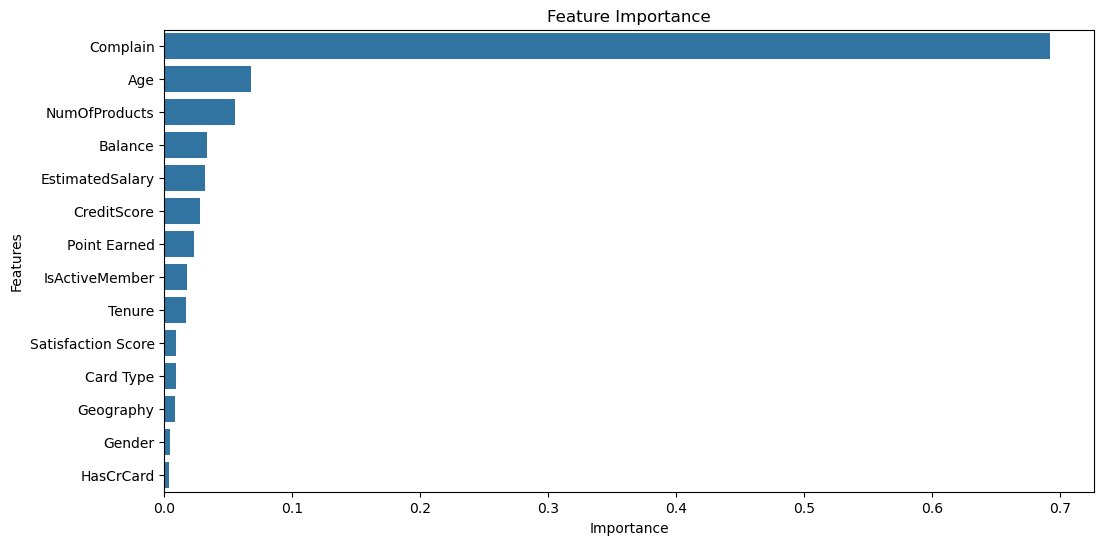

In [17]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

In [18]:
import joblib

joblib.dump(rf_model, "customer_churn_rf_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [19]:
joblib.dump(label_encoder, "label_encoder.pkl")

print("Encoder Saved Successfully!")

Encoder Saved Successfully!


In [20]:
loaded_model = joblib.load("customer_churn_rf_model.pkl")

loaded_model

RandomForestClassifier(random_state=42)

In [21]:
predictions = loaded_model.predict(X)

predictions[:10]

array([1, 0, 1, 0, 0, 1, 0, 1, 0, 0])

In [22]:
df['Predicted_Churn'] = predictions

In [23]:
df['Predicted_Churn'] = df['Predicted_Churn'].map({
    0:'Active',
    1:'Likely to Churn'
})

In [24]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,Predicted_Churn
0,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464,Likely to Churn
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456,Active
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377,Likely to Churn
3,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350,Active
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425,Active


In [25]:
df.to_csv("Customer_Churn_Predictions.csv", index=False)

print("Prediction File Saved")

Prediction File Saved


In [26]:
import json

columns = {
    "data_columns": list(X.columns)
}

with open("columns.json", "w") as f:
    json.dump(columns, f, indent=4)

print("columns.json created successfully!")

columns.json created successfully!


In [27]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned',
       'Predicted_Churn'],
      dtype='object')

In [28]:
df = df[[
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "Satisfaction Score",
    "EstimatedSalary",
    "Exited"
]]

In [29]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,Satisfaction Score,EstimatedSalary,Exited
0,619,42,2,0.00,1,2,101348.88,1
1,608,41,1,83807.86,1,3,112542.58,0
2,502,42,8,159660.80,3,3,113931.57,1
3,699,39,1,0.00,2,5,93826.63,0
4,850,43,2,125510.82,1,5,79084.10,0
...,...,...,...,...,...,...,...,...
995,610,29,9,0.00,3,5,83912.24,0
996,811,44,3,0.00,2,5,78439.73,0
997,587,62,7,121286.27,1,5,6776.92,0
998,811,28,4,167738.82,2,4,9903.42,0


In [30]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,Satisfaction Score,EstimatedSalary,Exited
0,619,42,2,0.00,1,2,101348.88,1
1,608,41,1,83807.86,1,3,112542.58,0
2,502,42,8,159660.80,3,3,113931.57,1
3,699,39,1,0.00,2,5,93826.63,0
4,850,43,2,125510.82,1,5,79084.10,0


In [31]:
import pandas as pd
import numpy as np
import json
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [33]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [35]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [36]:
y_pred = model.predict(X_test)

In [37]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.81


In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89       159
           1       0.62      0.20      0.30        41

    accuracy                           0.81       200
   macro avg       0.72      0.58      0.59       200
weighted avg       0.78      0.81      0.77       200



In [39]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[154   5]
 [ 33   8]]


In [40]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values("Importance", ascending=False)

,Feature,Importance
1,Age,0.236302
6,EstimatedSalary,0.160516
0,CreditScore,0.156905
3,Balance,0.149166
4,NumOfProducts,0.137225
2,Tenure,0.093116
5,Satisfaction Score,0.066770


In [41]:
import joblib

joblib.dump(model, "customer_churn_rf_model.pkl")

['customer_churn_rf_model.pkl']

In [42]:
columns = {
    "data_columns": list(X.columns)
}

with open("cols.json", "w") as f:
    json.dump(columns, f)